# 00 — 环境检查与安全连接 Quafu-SQC-SQC

目标：

1. 确认 notebook 正在使用 `QuantumComputing` 环境；
2. 确认 `quafusqc` 的实际版本和 import 名；
3. 生成一个最小 OpenQASM 2.0 线路；
4. 在不泄露 token、不意外提交任务的前提下准备云端连接。

**安全规则：** 不要把 token 粘贴进代码单元。此前出现在聊天或旧
notebook 中的 token 应当撤销，下面只接受环境变量或隐藏输入。

In [1]:
import os
import platform
import sys
from importlib.metadata import PackageNotFoundError, version

print("Python executable:", sys.executable)
print("Python version:", platform.python_version())

assert sys.version_info >= (3, 12), (
    "quafusqc 要求 Python >= 3.12。请从 QuantumComputing 环境启动 Jupyter。"
)

try:
    quafu_version = version("quafusqc")
except PackageNotFoundError as exc:
    raise RuntimeError(
        "当前 kernel 没有安装 quafusqc。请切换到 QuantumComputing 环境。"
    ) from exc

from quafu import Task

print("quafusqc version:", quafu_version)
print("import check: from quafu import Task  ✓")

Python executable: /opt/miniconda3/envs/QuantumComputing/bin/python
Python version: 3.13.7
quafusqc version: 3.3.9
import check: from quafu import Task  ✓


## 一个完全离线的 QASM 示例

`quafusqc` 接收 OpenQASM 2.0 字符串。生成字符串不需要 token，也不会联网。

In [2]:
bell_qasm = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];
"""

print(bell_qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];



## Qiskit 线路图：Bell 电路

下面把同一段 OpenQASM 2.0 解析为 Qiskit `QuantumCircuit`，再生成实际线路图。
这同时检查 QASM 是否能被独立解析。线路图只用于本地检查，不改变 Quafu-SQC 的
提交格式。

Qiskit version: 2.5.1
Parsed operations: OrderedDict({'measure': 2, 'h': 1, 'cx': 1})


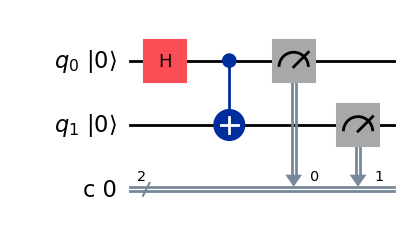

In [3]:
from pathlib import Path

import qiskit
from qiskit import qasm2

asset_dir = Path("../assets/circuits")
asset_dir.mkdir(parents=True, exist_ok=True)

bell_circuit = qasm2.loads(bell_qasm)
print("Qiskit version:", qiskit.__version__)
print("Parsed operations:", bell_circuit.count_ops())

bell_figure = bell_circuit.draw(
    output="mpl",
    fold=-1,
    idle_wires=False,
    initial_state=True,
)
bell_figure.savefig(
    asset_dir / "bell-circuit.png",
    dpi=180,
    bbox_inches="tight",
)
bell_figure

In [4]:
BACKEND = "Baihua"  # 运行时先看实时状态，再决定是否修改
SHOTS = 1024

bell_task = {
    "chip": BACKEND,
    "name": "qos_environment_smoke_test",
    "circuit": bell_qasm,
    "shots": SHOTS,
    "compile": True,
    "options": {
        "compiler": "quarkcircuit",
        "correct": False,
        "open_dd": None,
        "target_qubits": [],
    },
}

print("Dry-run task prepared. No network request was made.")
print({k: v for k, v in bell_task.items() if k != "circuit"})

Dry-run task prepared. No network request was made.
{'chip': 'Baihua', 'name': 'qos_environment_smoke_test', 'shots': 1024, 'compile': True, 'options': {'compiler': 'quarkcircuit', 'correct': False, 'open_dd': None, 'target_qubits': []}}


## 可选：实时查询后端

把下面的开关改成 `True` 才会联网。`Task(...)` 构造时就会验证 token。
如果环境变量中没有 token，`getpass` 会隐藏输入。

不调用 `tmgr.backend(...)`：本机当前未安装 QuarkStudio，而该辅助绘图路径
依赖 `quark.circuit`。任务状态、提交和结果获取不受影响。

In [5]:
CHECK_BACKEND_STATUS = False
tmgr = None

if CHECK_BACKEND_STATUS:
    from getpass import getpass

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入新生成的 Quafu-SQC token（输入不会显示）: "
    )
    tmgr = Task(token)
    backend_status = tmgr.status()
    print(backend_status)
else:
    print("Skipped network check. Set CHECK_BACKEND_STATUS=True when ready.")

Skipped network check. Set CHECK_BACKEND_STATUS=True when ready.


## 可选：提交最小任务

只有在已经查询实时后端状态、确认 QASM 和刷新凭据之后才开启。

In [6]:
SUBMIT_SMOKE_TEST = False
bell_tid = None

if SUBMIT_SMOKE_TEST:
    if tmgr is None:
        raise RuntimeError("请先运行实时后端检查，创建 tmgr。")
    bell_tid = tmgr.run(bell_task)
    print("Submitted task id:", bell_tid)
else:
    print("Submission disabled. Nothing was sent to Quafu.")

Submission disabled. Nothing was sent to Quafu.


### 通过标准

- Python 可执行文件应位于 `.../envs/QuantumComputing/bin/python`；
- `quafusqc version` 应为 `3.3.9` 或兼容的新版本；
- 默认完整运行本 notebook 时不产生任何云任务；
- notebook 源码和输出中不出现 token。